<a href="https://colab.research.google.com/github/tahminabintazaman-ux/waterlogging-severity-detection/blob/main/12_phase04_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PHASE 2

In [ ]:
# ============================================================
# PHASE 2: DATA COLLECTION, PREPROCESSING & EDA
# Project: Automated Waterlogging Severity Detection
# ============================================================

!pip install -q opendatasets

import os
import glob
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# ============================================================
# 1. DATA COLLECTION
# ============================================================

# Install Kaggle API
!pip install -q -U kaggle

import os
import shutil
from google.colab import files

# ------------------------------------------------------------
# Upload Kaggle API credentials
# ------------------------------------------------------------

print("Please upload your kaggle.json file.")

uploaded = files.upload()

# Create Kaggle configuration directory
os.makedirs("/root/.kaggle", exist_ok=True)

# Copy kaggle.json
shutil.copy(
    "kaggle.json",
    "/root/.kaggle/kaggle.json"
)

# Secure the credentials
os.chmod(
    "/root/.kaggle/kaggle.json",
    0o600
)

print("Kaggle API configured successfully.")

# ------------------------------------------------------------
# Download Dataset
# ------------------------------------------------------------

DATASET_NAME = "saurabhshahane/roadway-flooding-image-dataset"

!kaggle datasets download \
    -d saurabhshahane/roadway-flooding-image-dataset \
    -p /content \
    --unzip

# ------------------------------------------------------------
# Set correct dataset paths
# ------------------------------------------------------------

DATASET_DIR = "/content/Dataset"

IMAGE_DIR = os.path.join(
    DATASET_DIR,
    "images"
)

LABEL_DIR = os.path.join(
    DATASET_DIR,
    "labels"
)

# ------------------------------------------------------------
# Check dataset
# ------------------------------------------------------------

print("\nDataset directory:", DATASET_DIR)
print("Image directory:", IMAGE_DIR)
print("Label directory:", LABEL_DIR)

print("\nNumber of image files:",
      len(os.listdir(IMAGE_DIR)))

print("Number of label files:",
      len(os.listdir(LABEL_DIR)))

print("\nFirst 5 image files:")
print(os.listdir(IMAGE_DIR)[:5])

print("\nFirst 5 label files:")
print(os.listdir(LABEL_DIR)[:5])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 3.9 MB/s eta 0:00:00
Please upload your kaggle.json file.


Saving kaggle.json to kaggle.json
Kaggle API configured successfully.
Dataset URL: https://www.kaggle.com/datasets/saurabhshahane/roadway-flooding-image-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 16.1M/16.1M [00:00<00:00, 90.5MB/s]


Dataset directory: /content/Dataset
Image directory: /content/Dataset/images
Label directory: /content/Dataset/labels

Number of image files: 441
Number of label files: 441

First 5 image files:
['image_81.jpg', 'image_403.jpg', 'image_398.jpg', 'image_35.jpg', 'image_149.jpg']

First 5 label files:
['label_379.png', 'label_386.png', 'label_255.png', 'label_385.png', 'label_353.png']


In [ ]:
# ============================================================
# 2. DATASET STRUCTURE INSPECTION
# ============================================================

for root, dirs, files in os.walk(DATASET_DIR):
    level = root.replace(DATASET_DIR, "").count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    if level >= 2:
        continue

    for file in files[:10]:
        print(f"{indent}    {file}")

    if len(files) > 10:
        print(f"{indent}    ... {len(files)-10} more files")

Dataset/
    labels/
        label_379.png
        label_386.png
        label_255.png
        label_385.png
        label_353.png
        label_387.png
        label_314.png
        label_137.png
        label_170.png
        label_86.png
        ... 431 more files
    images/
        image_81.jpg
        image_403.jpg
        image_398.jpg
        image_35.jpg
        image_149.jpg
        image_385.jpg
        image_368.jpg
        image_115.jpg
        image_174.jpg
        image_386.jpg
        ... 431 more files


In [ ]:
# ============================================================
# 3. COLLECT IMAGE FILES
# ============================================================

image_extensions = ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG")

image_paths = []

for ext in image_extensions:
    image_paths.extend(
        glob.glob(
            os.path.join(DATASET_DIR, "**", ext),
            recursive=True
        )
    )

# Remove files that are likely masks/labels
image_paths = [
    p for p in image_paths
    if "mask" not in p.lower()
    and "label" not in p.lower()
]

image_paths = sorted(set(image_paths))

print("Total candidate images:", len(image_paths))

Total candidate images: 441


In [ ]:
# ============================================================
# 4. IMAGE VALIDITY CHECK
# ============================================================

valid_images = []
invalid_images = []

for img_path in image_paths:

    try:
        with Image.open(img_path) as img:
            img.verify()

        valid_images.append(img_path)

    except Exception as e:
        invalid_images.append({
            "file_path": img_path,
            "error": str(e)
        })

print("Valid images:", len(valid_images))
print("Invalid/corrupted images:", len(invalid_images))

if invalid_images:
    print("\nInvalid images:")
    display(pd.DataFrame(invalid_images).head())

Valid images: 441
Invalid/corrupted images: 0


In [ ]:
# ============================================================
# 5. DUPLICATE CHECK
# ============================================================

from hashlib import md5

hashes = {}
duplicate_files = []

for img_path in valid_images:

    try:
        with open(img_path, "rb") as f:
            file_hash = md5(f.read()).hexdigest()

        if file_hash in hashes:
            duplicate_files.append({
                "duplicate": img_path,
                "original": hashes[file_hash]
            })
        else:
            hashes[file_hash] = img_path

    except Exception:
        pass

print("Duplicate image files:", len(duplicate_files))

if duplicate_files:
    display(pd.DataFrame(duplicate_files).head())

Duplicate image files: 1


,duplicate,original
0,/content/Dataset/images/image_370.jpg,/content/Dataset/images/image_294.jpg


In [ ]:
# ============================================================
# 6. REMOVE DUPLICATES
# ============================================================

duplicate_paths = set(
    item["duplicate"]
    for item in duplicate_files
)

clean_image_paths = [
    p for p in valid_images
    if p not in duplicate_paths
]

print("Images before cleaning:", len(image_paths))
print("Invalid images:", len(invalid_images))
print("Duplicate images:", len(duplicate_files))
print("Final unique valid images:", len(clean_image_paths))

Images before cleaning: 441
Invalid images: 0
Duplicate images: 1
Final unique valid images: 440


In [ ]:
# ============================================================
# 7. MASK MATCHING
# ============================================================

def find_mask_path(img_path):
    """
    Try to locate the corresponding segmentation mask.
    """

    filename = os.path.basename(img_path)
    stem = os.path.splitext(filename)[0]

    possible_paths = [

        # images -> labels
        img_path.replace(
            os.sep + "images" + os.sep,
            os.sep + "labels" + os.sep
        ).replace(".jpg", ".png"),

        img_path.replace(
            os.sep + "images" + os.sep,
            os.sep + "labels" + os.sep
        ).replace(".JPG", ".png"),

        img_path.replace(
            os.sep + "images" + os.sep,
            os.sep + "labels" + os.sep
        ),

        # same directory
        os.path.join(os.path.dirname(img_path), stem + ".png"),

        os.path.join(os.path.dirname(img_path), stem + ".jpg")
    ]

    for path in possible_paths:
        if os.path.exists(path):
            return path

    # Search globally by filename stem
    possible_global = glob.glob(
        os.path.join(
            DATASET_DIR,
            "**",
            stem + ".*"
        ),
        recursive=True
    )

    for path in possible_global:

        if path == img_path:
            continue

        if "label" in path.lower() or "mask" in path.lower():
            return path

    return None


mask_results = []

for img_path in clean_image_paths:

    mask_path = find_mask_path(img_path)

    mask_results.append({
        "file_path": img_path,
        "mask_path": mask_path,
        "mask_exists": mask_path is not None
    })

mask_df = pd.DataFrame(mask_results)

print(
    "Images with masks:",
    mask_df["mask_exists"].sum()
)

print(
    "Images without masks:",
    (~mask_df["mask_exists"]).sum()
)

Images with masks: 440
Images without masks: 0


In [ ]:
# ============================================================
# 8. FEATURE EXTRACTION
# ============================================================

records = []

for _, row in mask_df.iterrows():

    img_path = row["file_path"]
    mask_path = row["mask_path"]

    try:

        with Image.open(img_path) as img:

            img_rgb = img.convert("RGB")

            width, height = img_rgb.size

            img_arr = np.array(img_rgb).astype(np.float32)

            brightness = np.mean(img_arr)

            contrast = np.std(img_arr)

            r_mean = np.mean(img_arr[:, :, 0])
            g_mean = np.mean(img_arr[:, :, 1])
            b_mean = np.mean(img_arr[:, :, 2])

        water_ratio = np.nan

        # ----------------------------------------------------
        # Calculate water coverage from mask
        # ----------------------------------------------------

        if mask_path is not None:

            with Image.open(mask_path) as mask:

                mask_arr = np.array(
                    mask.convert("L")
                )

                water_pixels = np.sum(mask_arr > 128)

                water_ratio = (
                    water_pixels /
                    float(mask_arr.size)
                )

        records.append({

            "file_path": img_path,

            "mask_path": mask_path,

            "mask_available": mask_path is not None,

            "width": width,

            "height": height,

            "brightness": brightness,

            "contrast": contrast,

            "r_mean": r_mean,

            "g_mean": g_mean,

            "b_mean": b_mean,

            "water_coverage_pct":
                water_ratio * 100
                if not np.isnan(water_ratio)
                else np.nan

        })

    except Exception as e:

        print("Could not process:", img_path)
        print("Reason:", e)


df = pd.DataFrame(records)

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (440, 11)


,file_path,mask_path,mask_available,width,height,brightness,contrast,r_mean,g_mean,b_mean,water_coverage_pct
0,/content/Dataset/images/image_1.jpg,/content/Dataset/images/image_1.jpg,True,512,384,100.310028,70.429070,104.965759,104.079651,91.884636,36.730957
1,/content/Dataset/images/image_10.jpg,/content/Dataset/images/image_10.jpg,True,512,384,146.090393,81.587128,147.742813,149.175003,141.353378,56.843058
2,/content/Dataset/images/image_100.jpg,/content/Dataset/images/image_100.jpg,True,512,384,115.816490,53.216797,120.184822,117.094421,110.170250,44.776408
3,/content/Dataset/images/image_101.jpg,/content/Dataset/images/image_101.jpg,True,512,384,125.877403,58.068802,129.907593,127.626259,120.098274,56.031291
4,/content/Dataset/images/image_102.jpg,/content/Dataset/images/image_102.jpg,True,512,384,116.689072,60.114082,115.943115,118.693886,115.430199,49.119059


In [ ]:
# ============================================================
# 9. MISSING VALUE ANALYSIS
# ============================================================

missing_values = df.isnull().sum()

missing_percentage = (
    df.isnull().mean() * 100
).round(2)

missing_summary = pd.DataFrame({
    "Missing_Count": missing_values,
    "Missing_Percentage": missing_percentage
})

display(missing_summary)

,Missing_Count,Missing_Percentage
file_path,0,0.0
mask_path,0,0.0
mask_available,0,0.0
width,0,0.0
height,0,0.0
brightness,0,0.0
contrast,0,0.0
r_mean,0,0.0
g_mean,0,0.0
b_mean,0,0.0


In [ ]:
# ============================================================
# 10. REMOVE IMAGES WITHOUT VALID MASKS
# ============================================================

before_mask_filter = len(df)

df = df[
    df["mask_available"] == True
].copy()

df = df[
    df["water_coverage_pct"].notna()
].copy()

after_mask_filter = len(df)

print("Images before mask filtering:", before_mask_filter)
print("Images after mask filtering:", after_mask_filter)
print(
    "Images removed:",
    before_mask_filter - after_mask_filter
)

Images before mask filtering: 440
Images after mask filtering: 440
Images removed: 0


In [ ]:
# ============================================================
# 11. IMAGE DIMENSION CONSISTENCY
# ============================================================

dimension_summary = (
    df.groupby(["width", "height"])
      .size()
      .reset_index(name="count")
      .sort_values("count", ascending=False)
)

display(dimension_summary)

print(
    "Number of unique image dimensions:",
    dimension_summary.shape[0]
)

,width,height,count
0,512,384,440


Number of unique image dimensions: 1


In [ ]:
# ============================================================
# 12. SEVERITY LABEL CREATION
# ============================================================

LOW_THRESHOLD = 15
HIGH_THRESHOLD = 35

def assign_severity(water_percentage):

    if water_percentage < LOW_THRESHOLD:
        return "Low"

    elif water_percentage <= HIGH_THRESHOLD:
        return "Medium"

    else:
        return "High"


df["severity"] = df[
    "water_coverage_pct"
].apply(assign_severity)

print("Severity labels created.")

display(
    df["severity"].value_counts()
)

Severity labels created.


,count
severity,
High,290
Medium,127
Low,23


### Severity Label Definition

For this project, roadway waterlogging severity is operationally
defined using the percentage of image area covered by water.

- Low: water coverage < 15%
- Medium: water coverage from 15% to 35%
- High: water coverage > 35%

These thresholds are project-defined operational criteria used to
convert the continuous water-coverage measurement into three
classification categories.

The thresholds should not be interpreted as universally accepted
real-world flood severity standards unless supported by the reviewed
literature.

In [ ]:
# ============================================================
# 13. CLASS DISTRIBUTION
# ============================================================

class_counts = (
    df["severity"]
    .value_counts()
    .reindex(["Low", "Medium", "High"])
)

class_percentages = (
    class_counts /
    class_counts.sum() *
    100
).round(2)

class_distribution = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages
})

display(class_distribution)

,Count,Percentage
severity,,
Low,23,5.23
Medium,127,28.86
High,290,65.91


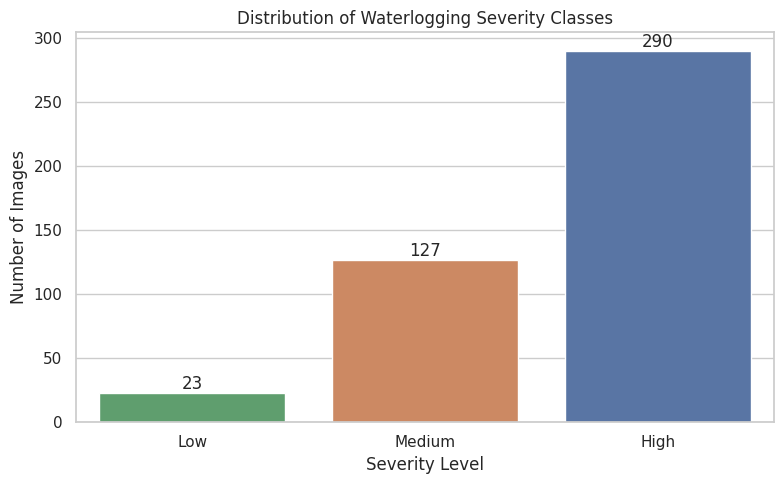

In [ ]:
# ============================================================
# 14. CLASS DISTRIBUTION VISUALIZATION
# ============================================================

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="severity",
    order=["Low", "Medium", "High"],
    hue="severity",
    legend=False
)

plt.title("Distribution of Waterlogging Severity Classes")
plt.xlabel("Severity Level")
plt.ylabel("Number of Images")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

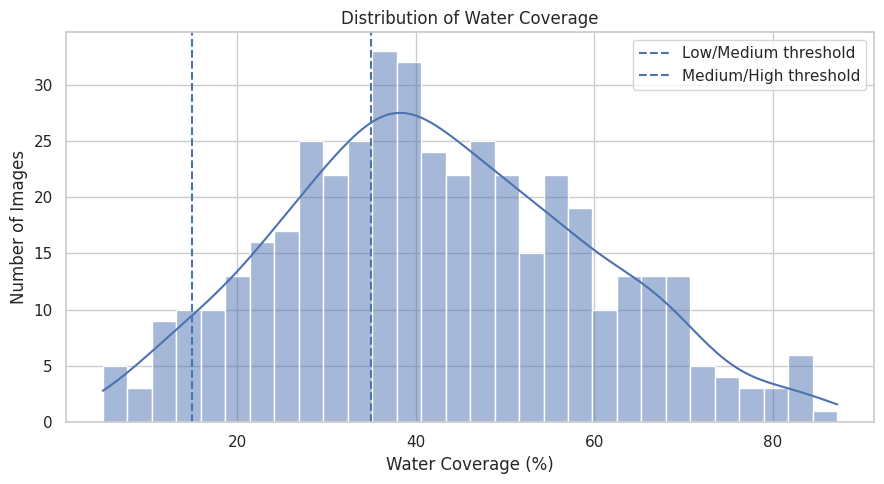

In [ ]:
# ============================================================
# 15. WATER COVERAGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="water_coverage_pct",
    bins=30,
    kde=True
)

plt.axvline(
    LOW_THRESHOLD,
    linestyle="--",
    label="Low/Medium threshold"
)

plt.axvline(
    HIGH_THRESHOLD,
    linestyle="--",
    label="Medium/High threshold"
)

plt.title("Distribution of Water Coverage")
plt.xlabel("Water Coverage (%)")
plt.ylabel("Number of Images")
plt.legend()

plt.tight_layout()
plt.show()

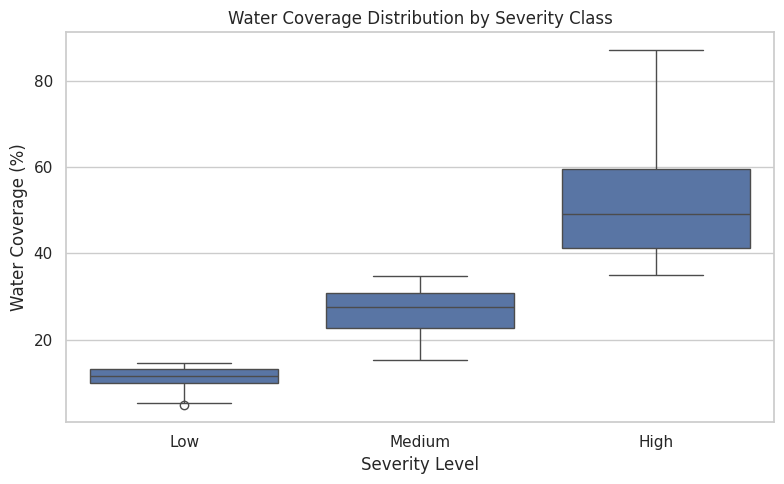

In [ ]:
# ============================================================
# 16. WATER COVERAGE BY SEVERITY
# ============================================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="severity",
    y="water_coverage_pct",
    order=["Low", "Medium", "High"]
)

plt.title(
    "Water Coverage Distribution by Severity Class"
)

plt.xlabel("Severity Level")
plt.ylabel("Water Coverage (%)")

plt.tight_layout()
plt.show()

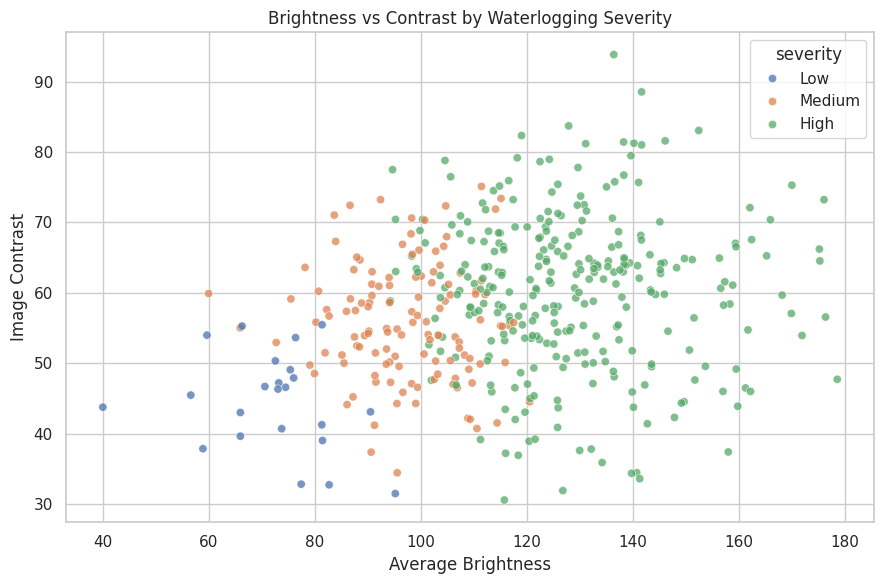

In [ ]:
# ============================================================
# 17. BRIGHTNESS VS CONTRAST
# ============================================================

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="brightness",
    y="contrast",
    hue="severity",
    hue_order=["Low", "Medium", "High"],
    alpha=0.75
)

plt.title(
    "Brightness vs Contrast by Waterlogging Severity"
)

plt.xlabel("Average Brightness")
plt.ylabel("Image Contrast")

plt.tight_layout()
plt.show()

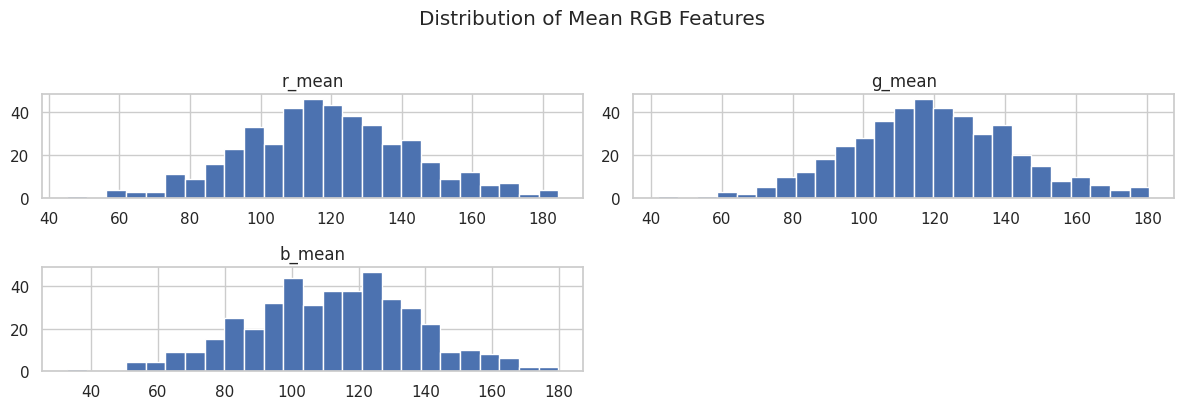

In [ ]:
# ============================================================
# 18. RGB FEATURE DISTRIBUTIONS
# ============================================================

rgb_columns = [
    "r_mean",
    "g_mean",
    "b_mean"
]

df[rgb_columns].hist(
    figsize=(12, 4),
    bins=25
)

plt.suptitle(
    "Distribution of Mean RGB Features",
    y=1.02
)

plt.tight_layout()
plt.show()

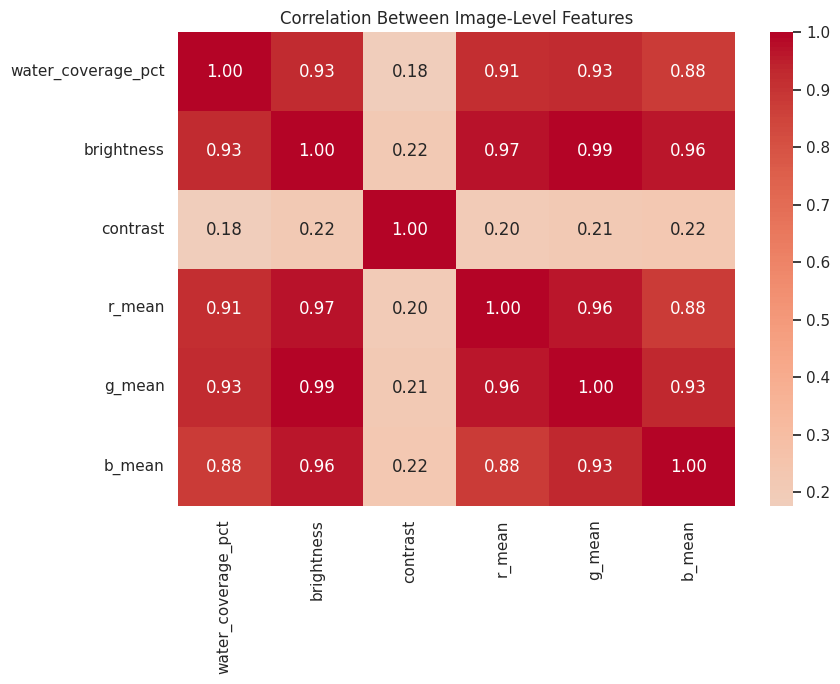

In [ ]:
# ============================================================
# 19. CORRELATION ANALYSIS
# ============================================================

numeric_columns = [
    "water_coverage_pct",
    "brightness",
    "contrast",
    "r_mean",
    "g_mean",
    "b_mean"
]

correlation_matrix = df[
    numeric_columns
].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Between Image-Level Features"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 20. OUTLIER ANALYSIS
# ============================================================

feature_columns = [
    "water_coverage_pct",
    "brightness",
    "contrast",
    "r_mean",
    "g_mean",
    "b_mean"
]

outlier_summary = []

for column in feature_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary.append({

        "Feature": column,

        "Q1": Q1,

        "Q3": Q3,

        "IQR": IQR,

        "Lower_Bound": lower_bound,

        "Upper_Bound": upper_bound,

        "Outlier_Count": len(outliers)

    })

outlier_df = pd.DataFrame(outlier_summary)

display(outlier_df)

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,water_coverage_pct,29.761251,54.571152,24.809901,-7.453601,91.786003,0
1,brightness,100.973688,132.221519,31.247831,54.101941,179.093266,1
2,contrast,50.581036,64.892048,14.311012,29.114517,86.358566,2
3,r_mean,102.397625,133.920952,31.523327,55.112635,181.205942,4
4,g_mean,103.768377,133.670372,29.901995,58.915385,178.523364,4
5,b_mean,96.015749,129.291874,33.276125,46.101562,179.206061,2


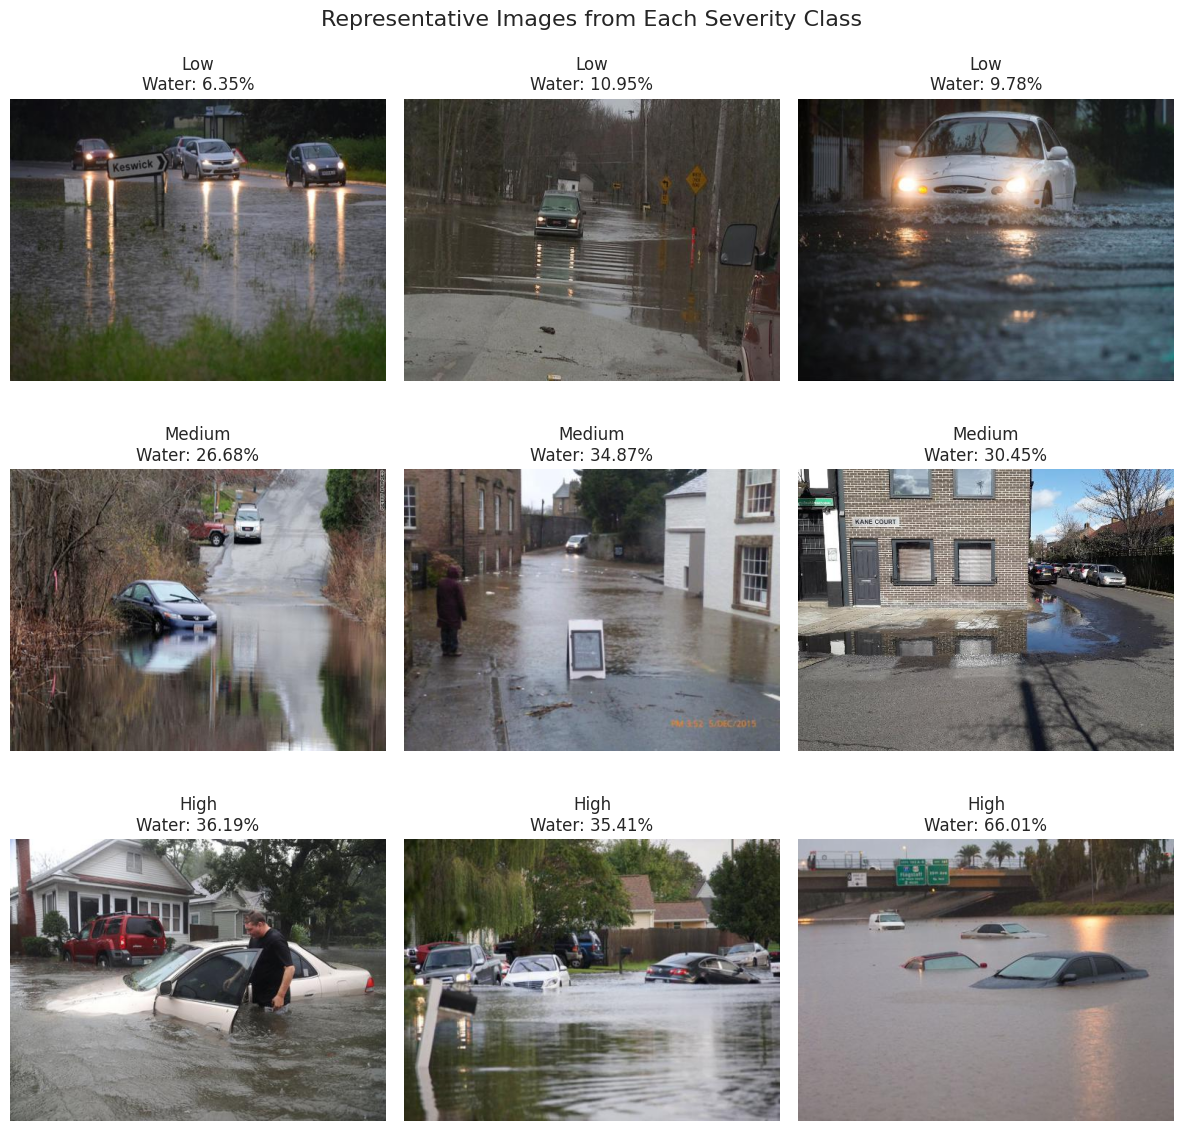

In [ ]:
# ============================================================
# 21. SAMPLE IMAGES FROM EACH SEVERITY CLASS
# ============================================================

fig, axes = plt.subplots(
    3, 3,
    figsize=(12, 12)
)

severity_order = ["Low", "Medium", "High"]

for row, severity in enumerate(severity_order):

    samples = df[
        df["severity"] == severity
    ].sample(
        min(3, len(df[df["severity"] == severity])),
        random_state=SEED
    )

    for col, (_, sample) in enumerate(samples.iterrows()):

        img = Image.open(
            sample["file_path"]
        ).convert("RGB")

        axes[row, col].imshow(img)

        axes[row, col].set_title(
            f"{severity}\n"
            f"Water: {sample['water_coverage_pct']:.2f}%"
        )

        axes[row, col].axis("off")

plt.suptitle(
    "Representative Images from Each Severity Class",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 22. FINAL DATASET SUMMARY
# ============================================================

print("=" * 60)
print("FINAL DATASET SUMMARY")
print("=" * 60)

print("Total images:", len(df))

print("\nImage dimensions:")
print(
    df[["width", "height"]]
    .drop_duplicates()
    .to_string(index=False)
)

print("\nSeverity distribution:")
print(
    df["severity"]
    .value_counts()
    .reindex(["Low", "Medium", "High"])
)

print("\nMissing values:")
print(
    df.isnull().sum()
)

print("\nDuplicate rows:")
print(
    df.duplicated().sum()
)

FINAL DATASET SUMMARY
Total images: 440

Image dimensions:
 width  height
   512     384

Severity distribution:
severity
Low        23
Medium    127
High      290
Name: count, dtype: int64

Missing values:
file_path             0
mask_path             0
mask_available        0
width                 0
height                0
brightness            0
contrast              0
r_mean                0
g_mean                0
b_mean                0
water_coverage_pct    0
severity              0
dtype: int64

Duplicate rows:
0


In [ ]:
# ============================================================
# 23. SAVE CLEANED METADATA
# ============================================================

OUTPUT_DIR = "./phase2_output"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

metadata_path = os.path.join(
    OUTPUT_DIR,
    "cleaned_waterlogging_metadata.csv"
)

df.to_csv(
    metadata_path,
    index=False
)

print(
    "Saved cleaned metadata to:",
    metadata_path
)

Saved cleaned metadata to: ./phase2_output/cleaned_waterlogging_metadata.csv


In [ ]:
# ============================================================
# 24. TRAIN / VALIDATION / TEST SPLIT
# ============================================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["severity"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["severity"],
    random_state=SEED
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTrain distribution:")
print(train_df["severity"].value_counts())

print("\nValidation distribution:")
print(val_df["severity"].value_counts())

print("\nTest distribution:")
print(test_df["severity"].value_counts())

Train: 308
Validation: 66
Test: 66

Train distribution:
severity
High      203
Medium     89
Low        16
Name: count, dtype: int64

Validation distribution:
severity
High      43
Medium    19
Low        4
Name: count, dtype: int64

Test distribution:
severity
High      44
Medium    19
Low        3
Name: count, dtype: int64


In [ ]:
# ============================================================
# 25. CHECK FOR DATA LEAKAGE
# ============================================================

train_paths = set(train_df["file_path"])
val_paths = set(val_df["file_path"])
test_paths = set(test_df["file_path"])

print(
    "Train ∩ Validation:",
    len(train_paths.intersection(val_paths))
)

print(
    "Train ∩ Test:",
    len(train_paths.intersection(test_paths))
)

print(
    "Validation ∩ Test:",
    len(val_paths.intersection(test_paths))
)

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [ ]:
# ============================================================
# 26. SAVE DATA SPLITS
# ============================================================

train_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "train_metadata.csv"
    ),
    index=False
)

val_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "validation_metadata.csv"
    ),
    index=False
)

test_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "test_metadata.csv"
    ),
    index=False
)

print("Train, validation and test metadata saved.")

Train, validation and test metadata saved.


In [ ]:
# ============================================================
# 27. IMAGE PREPROCESSING CONFIGURATION
# ============================================================

IMG_SIZE = (224, 224)

def preprocess_image(image_path):

    img = Image.open(
        image_path
    ).convert("RGB")

    # Resize
    img = img.resize(
        IMG_SIZE
    )

    # Convert to NumPy array
    img = np.array(img).astype(
        np.float32
    )

    # Normalize pixel values to [0, 1]
    img = img / 255.0

    return img


# Test preprocessing
sample_image = preprocess_image(
    train_df.iloc[0]["file_path"]
)

print("Processed image shape:", sample_image.shape)
print(
    "Pixel range:",
    sample_image.min(),
    "to",
    sample_image.max()
)

Processed image shape: (224, 224, 3)
Pixel range: 0.0 to 0.9411765


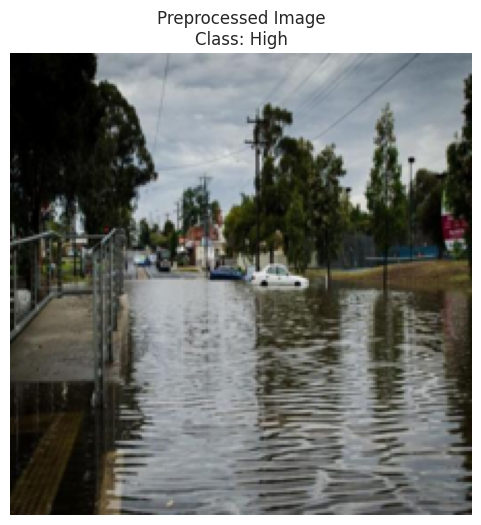

In [ ]:
# ============================================================
# 28. VERIFY IMAGE PREPROCESSING
# ============================================================

plt.figure(figsize=(6, 6))

plt.imshow(sample_image)

plt.title(
    f"Preprocessed Image\n"
    f"Class: {train_df.iloc[0]['severity']}"
)

plt.axis("off")

plt.show()

In [ ]:
# ============================================================
# 29. PHASE 2 SUMMARY TABLE
# ============================================================

phase2_summary = pd.DataFrame({

    "Item": [

        "Original candidate images",

        "Invalid/corrupted images",

        "Duplicate images",

        "Final valid images",

        "Images with usable masks",

        "Low severity images",

        "Medium severity images",

        "High severity images",

        "Training images",

        "Validation images",

        "Test images"

    ],

    "Value": [

        len(image_paths),

        len(invalid_images),

        len(duplicate_files),

        len(df),

        int(df["mask_available"].sum()),

        int((df["severity"] == "Low").sum()),

        int((df["severity"] == "Medium").sum()),

        int((df["severity"] == "High").sum()),

        len(train_df),

        len(val_df),

        len(test_df)

    ]

})

display(phase2_summary)

phase2_summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "phase2_summary.csv"
    ),
    index=False
)

,Item,Value
0,Original candidate images,441
1,Invalid/corrupted images,0
2,Duplicate images,1
3,Final valid images,440
4,Images with usable masks,440
5,Low severity images,23
6,Medium severity images,127
7,High severity images,290
8,Training images,308
9,Validation images,66


PHASE 3

In [ ]:
# ============================================================
# PHASE 3 - METHODOLOGY
# ============================================================

print("=" * 60)
print("PHASE 3 - METHODOLOGY")
print("=" * 60)

print("""
Research Problem:
Classify roadway images into three waterlogging severity classes:
Low, Medium, and High.

Problem Type:
Multi-class image classification.

Selected Models:
1. Custom CNN
2. VGG16 Transfer Learning
3. EfficientNetB0 Transfer Learning
""")

PHASE 3 - METHODOLOGY

Research Problem:
Classify roadway images into three waterlogging severity classes:
Low, Medium, and High.

Problem Type:
Multi-class image classification.

Selected Models:
1. Custom CNN
2. VGG16 Transfer Learning
3. EfficientNetB0 Transfer Learning



In [ ]:
# ============================================================
# VERIFY PHASE 2 OUTPUTS
# ============================================================

print("Checking Phase 2 variables...")

required_variables = [
    "train_df",
    "val_df",
    "test_df"
]

for variable in required_variables:

    if variable in globals():
        print(f"✓ {variable} found")
    else:
        print(f"✗ {variable} NOT found")

print("\nDataset sizes:")

print("Training   :", len(train_df))
print("Validation :", len(val_df))
print("Testing    :", len(test_df))

Checking Phase 2 variables...
✓ train_df found
✓ val_df found
✓ test_df found

Dataset sizes:
Training   : 308
Validation : 66
Testing    : 66


In [ ]:
# ============================================================
# CHECK DATAFRAME STRUCTURE
# ============================================================

print("Training dataframe columns:")
print(train_df.columns.tolist())

print("\nValidation dataframe columns:")
print(val_df.columns.tolist())

print("\nTesting dataframe columns:")
print(test_df.columns.tolist())

print("\nFirst 5 training rows:")
display(train_df.head())

Training dataframe columns:
['file_path', 'mask_path', 'mask_available', 'width', 'height', 'brightness', 'contrast', 'r_mean', 'g_mean', 'b_mean', 'water_coverage_pct', 'severity']

Validation dataframe columns:
['file_path', 'mask_path', 'mask_available', 'width', 'height', 'brightness', 'contrast', 'r_mean', 'g_mean', 'b_mean', 'water_coverage_pct', 'severity']

Testing dataframe columns:
['file_path', 'mask_path', 'mask_available', 'width', 'height', 'brightness', 'contrast', 'r_mean', 'g_mean', 'b_mean', 'water_coverage_pct', 'severity']

First 5 training rows:


,file_path,mask_path,mask_available,width,height,brightness,contrast,r_mean,g_mean,b_mean,water_coverage_pct,severity
102,/content/Dataset/images/image_191.jpg,/content/Dataset/images/image_191.jpg,True,512,384,95.255791,63.024277,95.086571,97.498749,93.182091,38.424174,High
103,/content/Dataset/images/image_192.jpg,/content/Dataset/images/image_192.jpg,True,512,384,122.201958,63.773018,125.568031,127.101807,113.936073,55.481974,High
148,/content/Dataset/images/image_232.jpg,/content/Dataset/images/image_232.jpg,True,512,384,125.077309,52.737675,126.402100,129.497726,119.332153,47.798157,High
150,/content/Dataset/images/image_234.jpg,/content/Dataset/images/image_234.jpg,True,512,384,98.261726,47.089622,104.755669,100.875763,89.153748,31.128947,Medium
277,/content/Dataset/images/image_349.jpg,/content/Dataset/images/image_349.jpg,True,512,384,98.265778,70.625137,101.771851,103.451782,89.573753,25.244649,Medium


In [ ]:
# ============================================================
# IDENTIFY IMAGE PATH AND LABEL COLUMNS
# ============================================================

possible_path_columns = [
    "file_path",
    "filepath",
    "image_path",
    "path",
    "image"
]

possible_label_columns = [
    "severity",
    "label",
    "class",
    "severity_label"
]

PATH_COLUMN = None
LABEL_COLUMN = None

for col in possible_path_columns:

    if col in train_df.columns:
        PATH_COLUMN = col
        break

for col in possible_label_columns:

    if col in train_df.columns:
        LABEL_COLUMN = col
        break

print("Image path column :", PATH_COLUMN)
print("Label column      :", LABEL_COLUMN)

Image path column : file_path
Label column      : severity


In [ ]:
# ============================================================
# CHECK CLASS LABELS
# ============================================================

print("Training class distribution:")
print(train_df[LABEL_COLUMN].value_counts())

print("\nValidation class distribution:")
print(val_df[LABEL_COLUMN].value_counts())

print("\nTest class distribution:")
print(test_df[LABEL_COLUMN].value_counts())

Training class distribution:
severity
High      203
Medium     89
Low        16
Name: count, dtype: int64

Validation class distribution:
severity
High      43
Medium    19
Low        4
Name: count, dtype: int64

Test class distribution:
severity
High      44
Medium    19
Low        3
Name: count, dtype: int64


In [ ]:
# ============================================================
# LABEL ENCODING
# ============================================================

class_names = ["Low", "Medium", "High"]

class_to_index = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

index_to_class = {
    0: "Low",
    1: "Medium",
    2: "High"
}

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["encoded_label"] = (
    train_df[LABEL_COLUMN]
    .map(class_to_index)
)

val_df["encoded_label"] = (
    val_df[LABEL_COLUMN]
    .map(class_to_index)
)

test_df["encoded_label"] = (
    test_df[LABEL_COLUMN]
    .map(class_to_index)
)

print(train_df["encoded_label"].value_counts().sort_index())

encoded_label
0     16
1     89
2    203
Name: count, dtype: int64


In [ ]:
# ============================================================
# CLASS IMBALANCE HANDLING
# ============================================================

import numpy as np

from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1, 2])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["encoded_label"].values
)

class_weights = {
    int(c): float(w)
    for c, w in zip(classes, weights)
}

print("Class weights:")

for c, w in class_weights.items():

    print(
        f"{index_to_class[c]} : {w:.4f}"
    )

Class weights:
Low : 6.4167
Medium : 1.1536
High : 0.5057


In [ ]:
# ============================================================
# DEEP LEARNING LIBRARIES
# ============================================================

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
# ============================================================
# REPRODUCIBILITY
# ============================================================

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed:", SEED)

Random seed: 42


In [ ]:
# ============================================================
# IMAGE DATA LOADER - CUSTOM CNN
# ============================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
NUM_CLASSES = 3


def load_image_cnn(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    ) / 255.0

    return image, label


def create_cnn_dataset(
    dataframe,
    shuffle=False
):

    paths = dataframe[PATH_COLUMN].values
    labels = dataframe["encoded_label"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    dataset = dataset.map(
        load_image_cnn,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:

        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED
        )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset

In [ ]:
# ============================================================
# CREATE CNN DATASETS
# ============================================================

train_ds = create_cnn_dataset(
    train_df,
    shuffle=True
)

val_ds = create_cnn_dataset(
    val_df
)

test_ds = create_cnn_dataset(
    test_df
)

print("CNN datasets created successfully.")

CNN datasets created successfully.


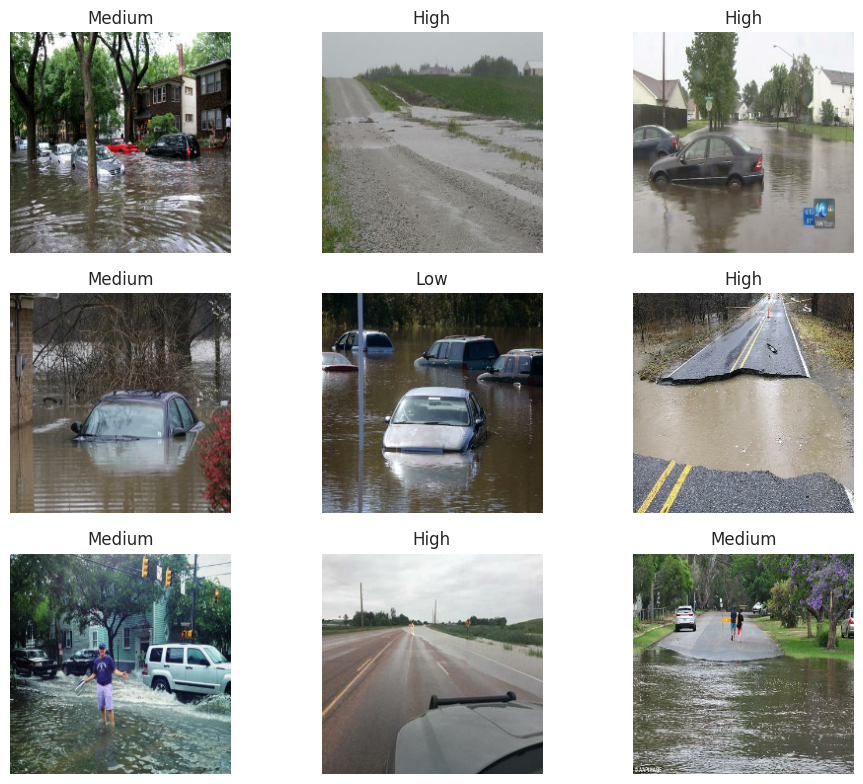

In [ ]:
# ============================================================
# VERIFY TRAINING IMAGES
# ============================================================

import matplotlib.pyplot as plt

images, labels = next(iter(train_ds))

plt.figure(figsize=(10, 8))

for i in range(min(9, len(images))):

    plt.subplot(3, 3, i + 1)

    plt.imshow(images[i])

    plt.title(
        index_to_class[int(labels[i])]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# MODEL 1 - CUSTOM CNN
# ============================================================

def build_custom_cnn():

    model = keras.Sequential([

        layers.Input(
            shape=(224, 224, 3)
        ),

        layers.Conv2D(
            32,
            (3, 3),
            activation="relu"
        ),

        layers.MaxPooling2D(),

        layers.Conv2D(
            64,
            (3, 3),
            activation="relu"
        ),

        layers.MaxPooling2D(),

        layers.Conv2D(
            128,
            (3, 3),
            activation="relu"
        ),

        layers.MaxPooling2D(),

        layers.Conv2D(
            256,
            (3, 3),
            activation="relu"
        ),

        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),

        layers.Dense(
            128,
            activation="relu"
        ),

        layers.Dropout(0.5),

        layers.Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    ])

    return model


cnn_model = build_custom_cnn()

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,699 (1.61 MB)

 Trainable params: 421,699 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# COMPILE CUSTOM CNN
# ============================================================

cnn_model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=0.0001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

print("Custom CNN compiled.")

Custom CNN compiled.


In [ ]:
# ============================================================
# CNN CALLBACKS
# ============================================================

cnn_callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7
    ),

    keras.callbacks.ModelCheckpoint(
        "best_custom_cnn.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [ ]:
# ============================================================
# TRAIN CUSTOM CNN
# ============================================================

cnn_history = cnn_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=30,

    class_weight=class_weights,

    callbacks=cnn_callbacks
)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 301ms/step - accuracy: 0.6136 - loss: 1.0948 - val_accuracy: 0.6515 - val_loss: 1.0607 - learning_rate: 1.0000e-04
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.6721 - loss: 1.0908 - val_accuracy: 0.6515 - val_loss: 1.0193 - learning_rate: 1.0000e-04
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6429 - loss: 1.0920 - val_accuracy: 0.6515 - val_loss: 1.0226 - learning_rate: 1.0000e-04
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.6591 - loss: 1.0802 - val_accuracy: 0.6515 - val_loss: 0.9841 - learning_rate: 1.0000e-04
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.6526 - loss: 1.0734 - val_accuracy: 0.6667 - val_loss: 0.9510 - learning_rate: 1.0000e-04
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6558 - loss: 1.0449 - val_accuracy: 0.6970 - val_loss: 0.9236 - learning_rate: 1.0000e-04
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.639

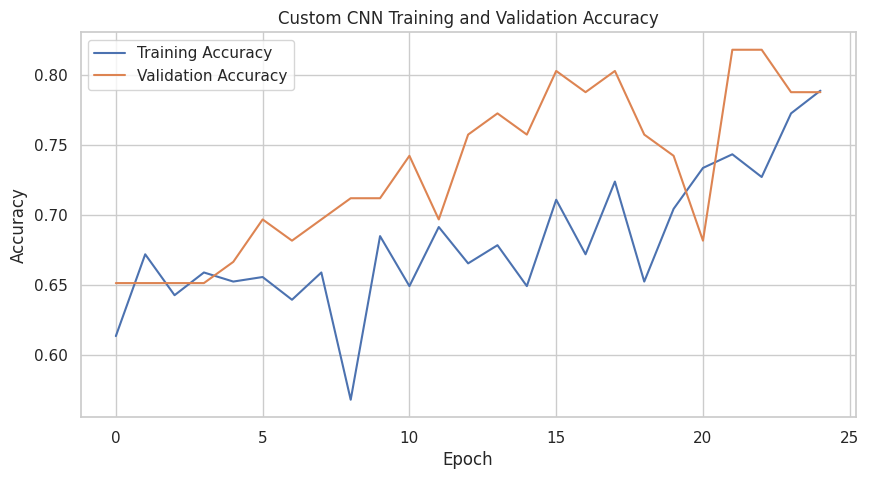

In [ ]:
# ============================================================
# CUSTOM CNN TRAINING CURVES
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    cnn_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    cnn_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Custom CNN Training and Validation Accuracy"
)

plt.legend()

plt.show()

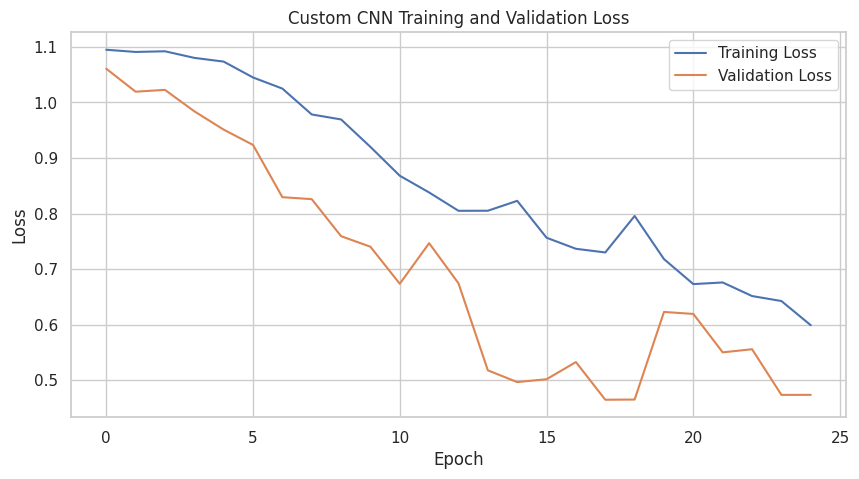

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    cnn_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    cnn_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Custom CNN Training and Validation Loss"
)

plt.legend()

plt.show()

In [ ]:
# ============================================================
# MODEL EVALUATION FUNCTION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


def evaluate_model(
    model,
    dataset,
    dataframe,
    model_name
):

    y_true = dataframe[
        "encoded_label"
    ].values

    probabilities = model.predict(
        dataset,
        verbose=0
    )

    y_pred = np.argmax(
        probabilities,
        axis=1
    )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    print("\n" + "=" * 60)

    print(model_name)

    print("=" * 60)

    print(
        f"Accuracy  : {accuracy:.4f}"
    )

    print(
        f"Precision : {precision:.4f}"
    )

    print(
        f"Recall    : {recall:.4f}"
    )

    print(
        f"Macro F1  : {macro_f1:.4f}"
    )

    print("\nClassification Report:")

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names,
            zero_division=0
        )
    )

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(figsize=(7, 6))

    plt.imshow(cm)

    plt.xticks(
        range(NUM_CLASSES),
        class_names
    )

    plt.yticks(
        range(NUM_CLASSES),
        class_names
    )

    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")

    plt.title(
        model_name + " - Confusion Matrix"
    )

    for i in range(NUM_CLASSES):

        for j in range(NUM_CLASSES):

            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.colorbar()

    plt.tight_layout()

    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Macro F1": macro_f1
    }


Custom CNN
Accuracy  : 0.7273
Precision : 0.5670
Recall    : 0.5369
Macro F1  : 0.5424

Classification Report:
              precision    recall  f1-score   support

         Low       0.33      0.33      0.33         3
      Medium       0.58      0.37      0.45        19
        High       0.78      0.91      0.84        44

    accuracy                           0.73        66
   macro avg       0.57      0.54      0.54        66
weighted avg       0.71      0.73      0.71        66



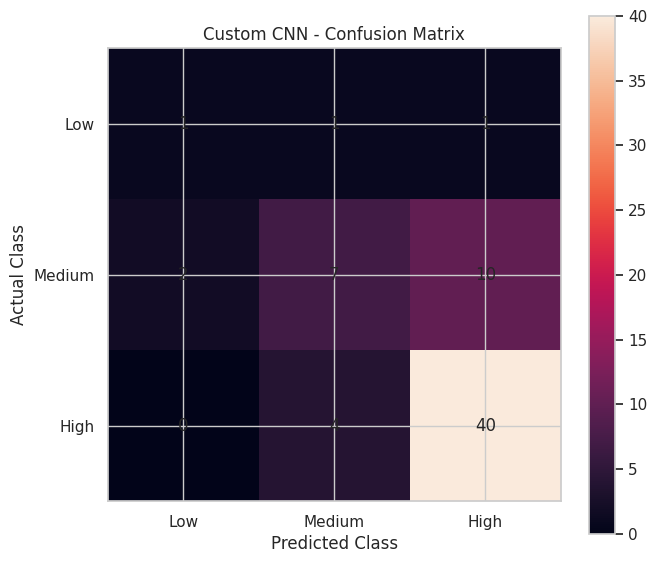

In [ ]:
# ============================================================
# EVALUATE CUSTOM CNN
# ============================================================

cnn_result = evaluate_model(
    cnn_model,
    test_ds,
    test_df,
    "Custom CNN"
)

In [ ]:
# ============================================================
# MODEL 2 - VGG16 TRANSFER LEARNING
# ============================================================

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input


vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
vgg_base.trainable = False

vgg_model = keras.Sequential([

    layers.Input(
        shape=(224, 224, 3)
    ),

    vgg_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        256,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,787 (56.64 MB)

 Trainable params: 132,099 (516.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# ============================================================
# VGG16 IMAGE PREPROCESSING
# ============================================================

def load_image_vgg(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    image = preprocess_input(
        image
    )

    return image, label


def create_vgg_dataset(
    dataframe,
    shuffle=False
):

    paths = dataframe[
        PATH_COLUMN
    ].values

    labels = dataframe[
        "encoded_label"
    ].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    dataset = dataset.map(
        load_image_vgg,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:

        dataset = dataset.shuffle(
            len(dataframe),
            seed=SEED
        )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset


vgg_train_ds = create_vgg_dataset(
    train_df,
    shuffle=True
)

vgg_val_ds = create_vgg_dataset(
    val_df
)

vgg_test_ds = create_vgg_dataset(
    test_df
)

print("VGG16 datasets created.")

VGG16 datasets created.


In [ ]:
# ============================================================
# COMPILE VGG16
# ============================================================

vgg_model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=0.0001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

In [ ]:
# ============================================================
# TRAIN VGG16
# ============================================================

vgg_callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7
    ),

    keras.callbacks.ModelCheckpoint(
        "best_vgg16.keras",
        monitor="val_loss",
        save_best_only=True
    )
]


vgg_history = vgg_model.fit(

    vgg_train_ds,

    validation_data=vgg_val_ds,

    epochs=30,

    class_weight=class_weights,

    callbacks=vgg_callbacks
)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 464ms/step - accuracy: 0.3604 - loss: 3.8952 - val_accuracy: 0.4697 - val_loss: 1.5268 - learning_rate: 1.0000e-04
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - accuracy: 0.4123 - loss: 3.2996 - val_accuracy: 0.6212 - val_loss: 1.2639 - learning_rate: 1.0000e-04
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - accuracy: 0.4675 - loss: 2.9200 - val_accuracy: 0.5606 - val_loss: 1.3617 - learning_rate: 1.0000e-04
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - accuracy: 0.3799 - loss: 3.0797 - val_accuracy: 0.5000 - val_loss: 1.4489 - learning_rate: 1.0000e-04
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - accuracy: 0.4448 - loss: 2.0261 - val_accuracy: 0.5606 - val_loss: 1.2185 - learning_rate: 1.0000e-04
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 133ms/step - accuracy: 0.4351 - loss: 2.1266 - val_accuracy: 0.5909 - val_loss: 1.1625 - learning_rate: 1.0000e-04
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - accuracy:


VGG16 Transfer Learning
Accuracy  : 0.6515
Precision : 0.4220
Recall    : 0.4055
Macro F1  : 0.4133

Classification Report:
              precision    recall  f1-score   support

         Low       0.00      0.00      0.00         3
      Medium       0.47      0.42      0.44        19
        High       0.80      0.80      0.80        44

    accuracy                           0.65        66
   macro avg       0.42      0.41      0.41        66
weighted avg       0.67      0.65      0.66        66



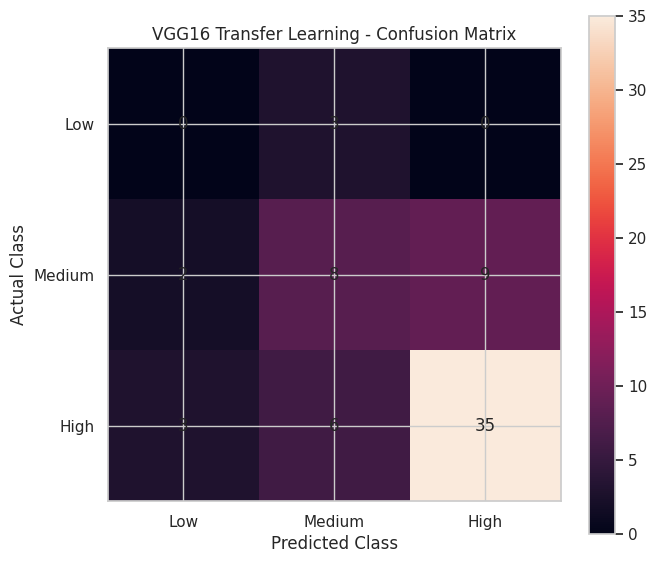

In [ ]:
# ============================================================
# EVALUATE VGG16
# ============================================================

vgg_result = evaluate_model(
    vgg_model,
    vgg_test_ds,
    test_df,
    "VGG16 Transfer Learning"
)

In [ ]:
# ============================================================
# MODEL 3 - EFFICIENTNETB0 TRANSFER LEARNING
# ============================================================

from tensorflow.keras.applications import EfficientNetB0


efficient_base = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

efficient_base.trainable = False

efficient_model = keras.Sequential([

    layers.Input(
        shape=(224, 224, 3)
    ),

    efficient_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        256,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

efficient_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,278 (16.70 MB)

 Trainable params: 328,707 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# ============================================================
# EFFICIENTNET IMAGE DATASET
# ============================================================

def load_image_efficientnet(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image, label


def create_efficientnet_dataset(
    dataframe,
    shuffle=False
):

    paths = dataframe[
        PATH_COLUMN
    ].values

    labels = dataframe[
        "encoded_label"
    ].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    dataset = dataset.map(
        load_image_efficientnet,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:

        dataset = dataset.shuffle(
            len(dataframe),
            seed=SEED
        )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset


efficient_train_ds = create_efficientnet_dataset(
    train_df,
    shuffle=True
)

efficient_val_ds = create_efficientnet_dataset(
    val_df
)

efficient_test_ds = create_efficientnet_dataset(
    test_df
)

print("EfficientNetB0 datasets created.")

EfficientNetB0 datasets created.


In [ ]:
# ============================================================
# COMPILE EFFICIENTNETB0
# ============================================================

efficient_model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=0.0001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

In [ ]:
# ============================================================
# TRAIN EFFICIENTNETB0
# ============================================================

efficient_callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7
    ),

    keras.callbacks.ModelCheckpoint(
        "best_efficientnetb0.keras",
        monitor="val_loss",
        save_best_only=True
    )
]


efficient_history = efficient_model.fit(

    efficient_train_ds,

    validation_data=efficient_val_ds,

    epochs=30,

    class_weight=class_weights,

    callbacks=efficient_callbacks
)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.4383 - loss: 1.1274 - val_accuracy: 0.5455 - val_loss: 0.9744 - learning_rate: 1.0000e-04
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.4253 - loss: 1.1158 - val_accuracy: 0.6364 - val_loss: 0.9299 - learning_rate: 1.0000e-04
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.5292 - loss: 1.0089 - val_accuracy: 0.5758 - val_loss: 0.9630 - learning_rate: 1.0000e-04
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.5130 - loss: 0.9594 - val_accuracy: 0.5758 - val_loss: 0.9641 - learning_rate: 1.0000e-04
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.5032 - loss: 0.9365 - val_accuracy: 0.5909 - val_loss: 0.9377 - learning_rate: 1.0000e-04
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.6039 - loss: 0.8172 - val_accuracy: 0.6061 - val_loss: 0.9268 - learning_rate: 5.0000e-05
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.5942 -


EfficientNetB0 Transfer Learning
Accuracy  : 0.7121
Precision : 0.4712
Recall    : 0.4856
Macro F1  : 0.4746

Classification Report:
              precision    recall  f1-score   support

         Low       0.00      0.00      0.00         3
      Medium       0.54      0.68      0.60        19
        High       0.87      0.77      0.82        44

    accuracy                           0.71        66
   macro avg       0.47      0.49      0.47        66
weighted avg       0.74      0.71      0.72        66



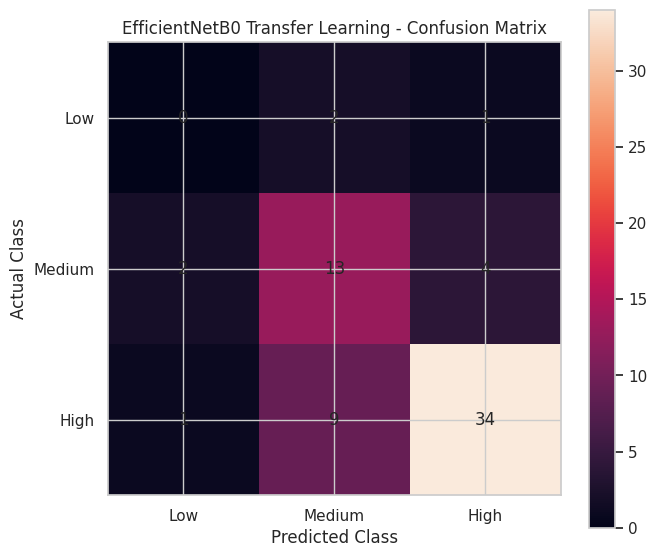

In [ ]:
# ============================================================
# EVALUATE EFFICIENTNETB0
# ============================================================

efficient_result = evaluate_model(
    efficient_model,
    efficient_test_ds,
    test_df,
    "EfficientNetB0 Transfer Learning"
)

In [ ]:
# ============================================================
# MODEL COMPARISON
# ============================================================

results = pd.DataFrame([

    cnn_result,
    vgg_result,
    efficient_result

])

print("\nMODEL COMPARISON")
display(results)


MODEL COMPARISON


,Model,Accuracy,Precision,Recall,Macro F1
0,Custom CNN,0.727273,0.566993,0.536948,0.542350
1,VGG16 Transfer Learning,0.651515,0.422014,0.405502,0.413300
2,EfficientNetB0 Transfer Learning,0.712121,0.471154,0.485646,0.474643


In [ ]:
# ============================================================
# BEST MODEL
# ============================================================

best_index = results["Macro F1"].idxmax()

best_model_result = results.loc[
    best_index
]

print("Best model based on Macro F1:")
print()

print(
    best_model_result.to_string()
)

Best model based on Macro F1:

Model        Custom CNN
Accuracy       0.727273
Precision      0.566993
Recall         0.536948
Macro F1        0.54235


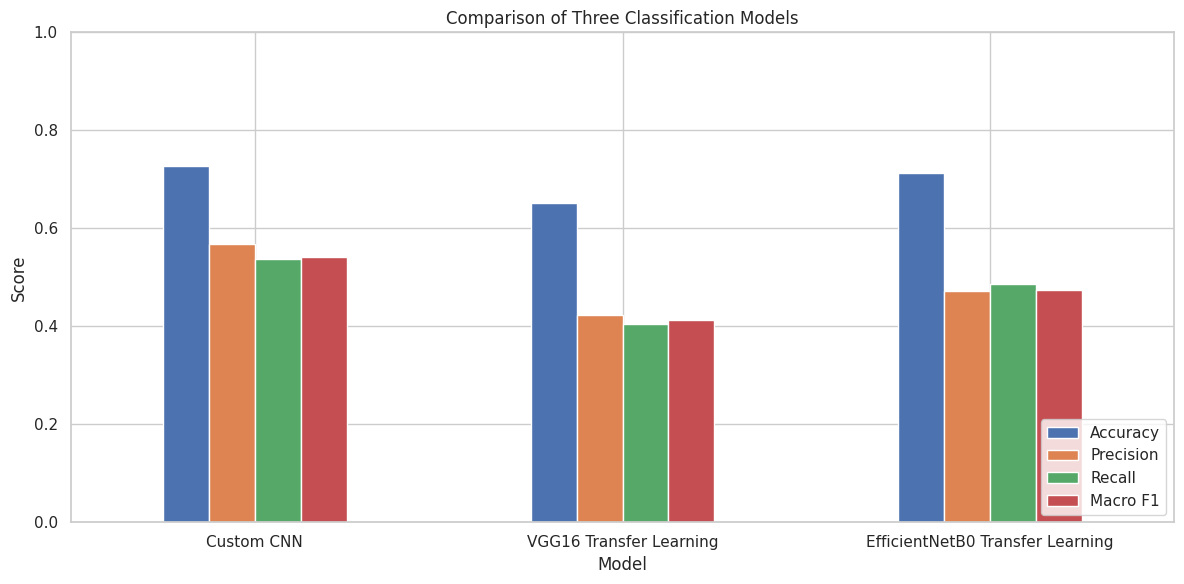

In [ ]:
# ============================================================
# MODEL PERFORMANCE COMPARISON
# ============================================================

comparison_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "Macro F1"
]

plot_data = results.set_index(
    "Model"
)[comparison_metrics]

plot_data.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Comparison of Three Classification Models"
)

plt.ylabel("Score")

plt.xlabel("Model")

plt.ylim(0, 1)

plt.xticks(
    rotation=0
)

plt.legend(
    loc="lower right"
)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# SAVE PHASE 3 RESULTS
# ============================================================

PHASE3_OUTPUT_DIR = "./phase3_output"

os.makedirs(
    PHASE3_OUTPUT_DIR,
    exist_ok=True
)

results.to_csv(
    os.path.join(
        PHASE3_OUTPUT_DIR,
        "model_comparison.csv"
    ),
    index=False
)

print(
    "Results saved to:",
    PHASE3_OUTPUT_DIR
)

Results saved to: ./phase3_output


Phase 4

In [ ]:
# ============================================================
# PHASE 4 - EVALUATION AND ANALYSIS
# ============================================================

print("=" * 70)
print("PHASE 4 - EVALUATION, ANALYSIS AND DISCUSSION")
print("=" * 70)

print("""
This phase evaluates the trained models, compares their performance,
examines the contribution of class weighting, interprets the results,
and identifies limitations and future improvements.
""")

PHASE 4 - EVALUATION, ANALYSIS AND DISCUSSION

This phase evaluates the trained models, compares their performance,
examines the contribution of class weighting, interprets the results,
and identifies limitations and future improvements.



In [ ]:
# ============================================================
# 1. FINAL MODEL EVALUATION
# ============================================================

print("FINAL MODEL PERFORMANCE")
print("=" * 70)

display(results.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True))

FINAL MODEL PERFORMANCE


,Model,Accuracy,Precision,Recall,Macro F1
0,Custom CNN,0.727273,0.566993,0.536948,0.542350
1,EfficientNetB0 Transfer Learning,0.712121,0.471154,0.485646,0.474643
2,VGG16 Transfer Learning,0.651515,0.422014,0.405502,0.413300


In [ ]:
# ============================================================
# BEST MODEL
# ============================================================

best_model_name = results.loc[
    results["Macro F1"].idxmax(),
    "Model"
]

best_f1 = results["Macro F1"].max()

print("Best Model :", best_model_name)
print("Best Macro F1 :", f"{best_f1:.4f}")

Best Model : Custom CNN
Best Macro F1 : 0.5424


In [ ]:
# ============================================================
# PER-CLASS PERFORMANCE - BEST MODEL
# ============================================================

def get_predictions(model, dataset):

    probabilities = model.predict(
        dataset,
        verbose=0
    )

    return np.argmax(
        probabilities,
        axis=1
    )


best_predictions = get_predictions(
    cnn_model,
    test_ds
)

y_test = test_df[
    "encoded_label"
].values

print("CUSTOM CNN - PER CLASS PERFORMANCE")
print("=" * 70)

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=class_names,
        zero_division=0
    )
)

CUSTOM CNN - PER CLASS PERFORMANCE
              precision    recall  f1-score   support

         Low       0.33      0.33      0.33         3
      Medium       0.58      0.37      0.45        19
        High       0.78      0.91      0.84        44

    accuracy                           0.73        66
   macro avg       0.57      0.54      0.54        66
weighted avg       0.71      0.73      0.71        66



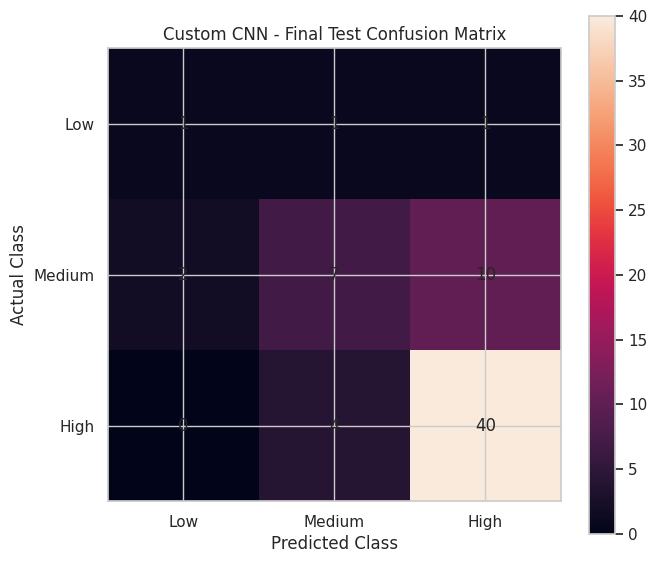

In [ ]:
# ============================================================
# BEST MODEL CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.xticks(
    range(NUM_CLASSES),
    class_names
)

plt.yticks(
    range(NUM_CLASSES),
    class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title(
    "Custom CNN - Final Test Confusion Matrix"
)

for i in range(NUM_CLASSES):

    for j in range(NUM_CLASSES):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()

plt.show()

,Model,Accuracy,Precision,Recall,Macro F1
0,Custom CNN,0.727273,0.566993,0.536948,0.542350
2,EfficientNetB0 Transfer Learning,0.712121,0.471154,0.485646,0.474643
1,VGG16 Transfer Learning,0.651515,0.422014,0.405502,0.413300


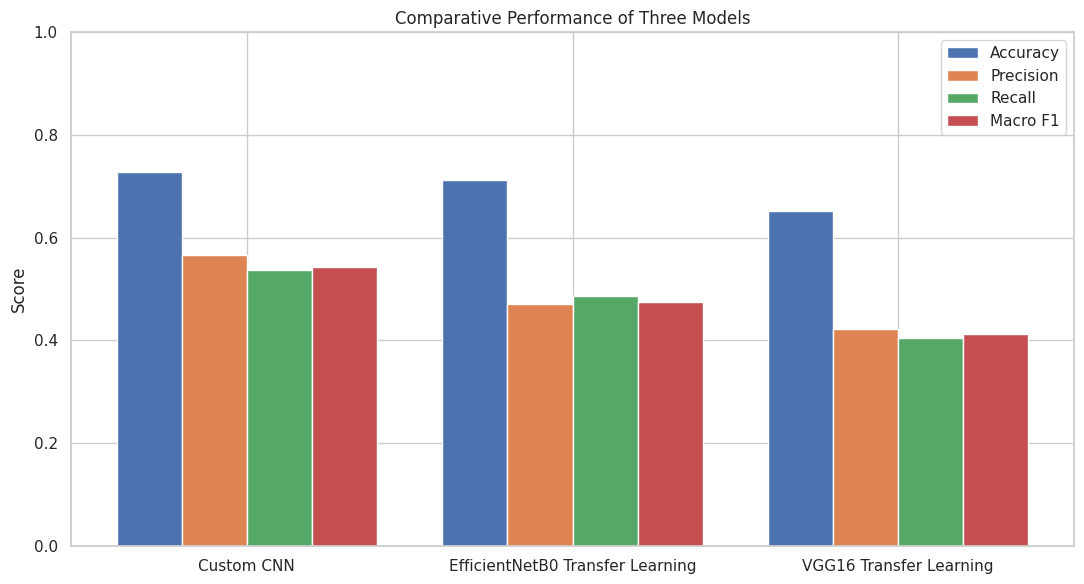

In [ ]:
# ============================================================
# 4. COMPARATIVE MODEL ANALYSIS
# ============================================================

comparison = results.copy()

comparison = comparison.sort_values(
    by="Macro F1",
    ascending=False
)

display(comparison)

plt.figure(figsize=(11, 6))

x = np.arange(len(comparison))
width = 0.2

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "Macro F1"
]

for i, metric in enumerate(metrics):

    plt.bar(
        x + (i - 1.5) * width,
        comparison[metric],
        width,
        label=metric
    )

plt.xticks(
    x,
    comparison["Model"],
    rotation=0
)

plt.ylabel("Score")
plt.ylim(0, 1)

plt.title(
    "Comparative Performance of Three Models"
)

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# 5. ABLATION STUDY
# CUSTOM CNN WITHOUT CLASS WEIGHTS
# ============================================================

print("Training ablation model without class weights...")

cnn_no_weights = build_custom_cnn()

cnn_no_weights.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=0.0001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

ablation_callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
]

ablation_history = cnn_no_weights.fit(

    train_ds,

    validation_data=val_ds,

    epochs=20,

    callbacks=ablation_callbacks,

    verbose=1
)

Training ablation model without class weights...
Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 269ms/step - accuracy: 0.6266 - loss: 0.9439 - val_accuracy: 0.6515 - val_loss: 0.7716
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.6494 - loss: 0.7936 - val_accuracy: 0.6515 - val_loss: 0.7327
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6429 - loss: 0.7650 - val_accuracy: 0.6515 - val_loss: 0.7341
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.6591 - loss: 0.7271 - val_accuracy: 0.6515 - val_loss: 0.7249
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.6461 - loss: 0.7570 - val_accuracy: 0.6515 - val_loss: 0.7221
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6558 - loss: 0.7578 - val_accuracy: 0.6515 - val_loss: 0.7136
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6623 - loss: 0.7395 - val_accuracy: 0.6515 - val_loss: 0.6939
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accurac

In [ ]:
# ============================================================
# EVALUATE ABLATION MODEL
# ============================================================

ablation_probabilities = cnn_no_weights.predict(
    test_ds,
    verbose=0
)

ablation_predictions = np.argmax(
    ablation_probabilities,
    axis=1
)

ablation_accuracy = accuracy_score(
    y_test,
    ablation_predictions
)

ablation_precision = precision_score(
    y_test,
    ablation_predictions,
    average="macro",
    zero_division=0
)

ablation_recall = recall_score(
    y_test,
    ablation_predictions,
    average="macro",
    zero_division=0
)

ablation_f1 = f1_score(
    y_test,
    ablation_predictions,
    average="macro",
    zero_division=0
)

ablation_result = {

    "Model": "Custom CNN - Without Class Weights",

    "Accuracy": ablation_accuracy,

    "Precision": ablation_precision,

    "Recall": ablation_recall,

    "Macro F1": ablation_f1
}

print(
    pd.Series(ablation_result)
)

Model        Custom CNN - Without Class Weights
Accuracy                               0.757576
Precision                              0.468187
Recall                                 0.478469
Macro F1                               0.471924
dtype: object


In [ ]:
# ============================================================
# ABLATION COMPARISON
# ============================================================

weighted_result = cnn_result.copy()

weighted_result["Model"] = (
    "Custom CNN - With Class Weights"
)

ablation_comparison = pd.DataFrame([

    weighted_result,

    ablation_result

])

print("ABLATION STUDY RESULTS")

display(
    ablation_comparison
)

ABLATION STUDY RESULTS


,Model,Accuracy,Precision,Recall,Macro F1
0,Custom CNN - With Class Weights,0.727273,0.566993,0.536948,0.542350
1,Custom CNN - Without Class Weights,0.757576,0.468187,0.478469,0.471924


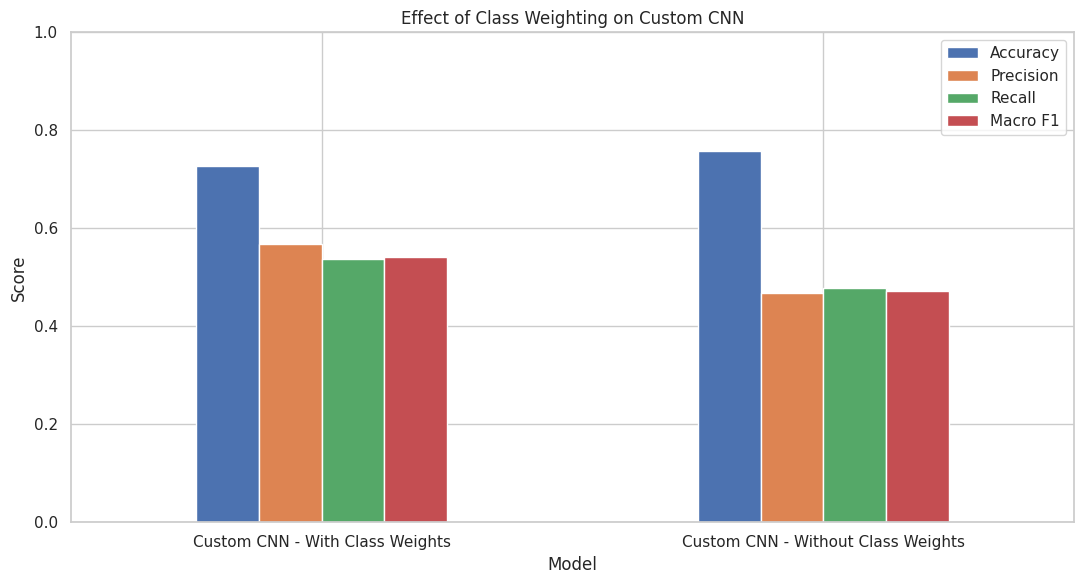

In [ ]:
# ============================================================
# ABLATION STUDY CHART
# ============================================================

ablation_plot = ablation_comparison.set_index(
    "Model"
)[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "Macro F1"
    ]
]

ablation_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "Effect of Class Weighting on Custom CNN"
)

plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(
    rotation=0
)

plt.legend()

plt.tight_layout()

plt.show()

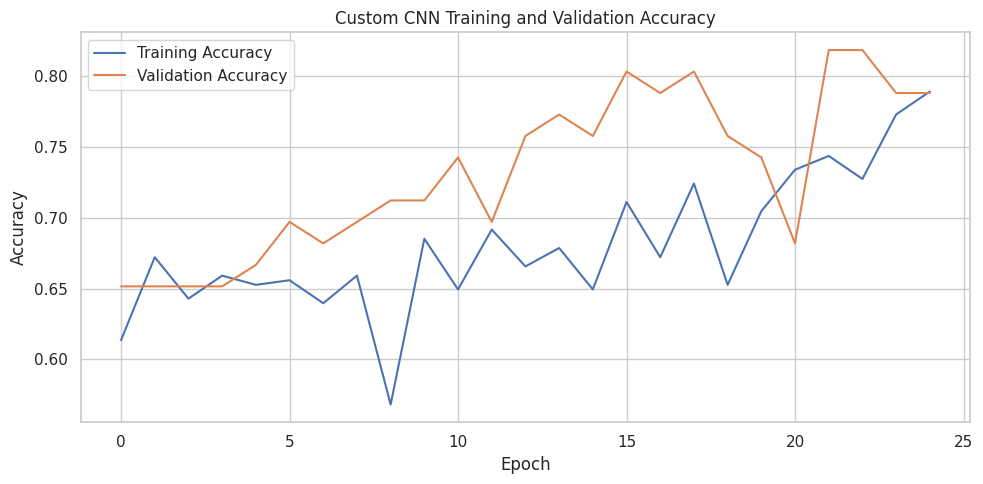

In [ ]:
# ============================================================
# TRAINING BEHAVIOR
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    cnn_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    cnn_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Custom CNN Training and Validation Accuracy"
)

plt.legend()

plt.tight_layout()

plt.show()

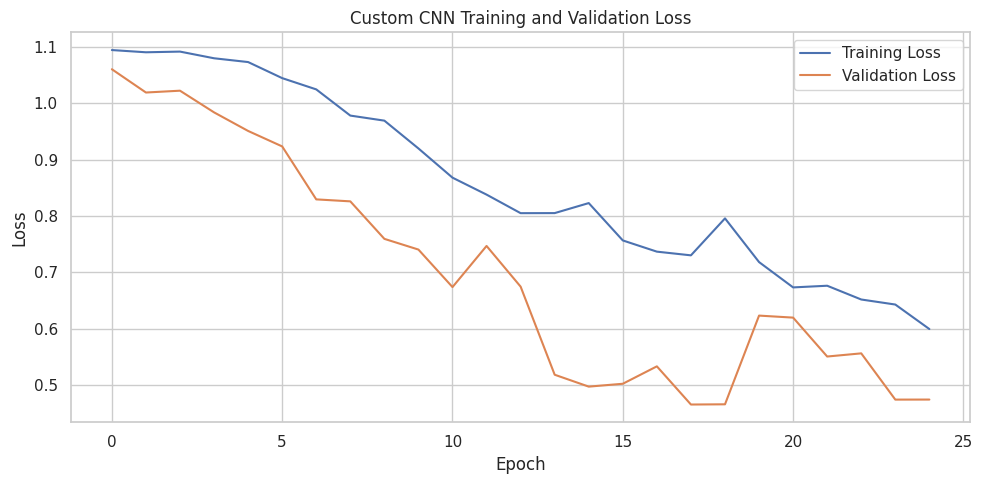

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    cnn_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    cnn_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Custom CNN Training and Validation Loss"
)

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# SAVE PHASE 4 RESULTS
# ============================================================

PHASE4_OUTPUT_DIR = "./phase4_output"

os.makedirs(
    PHASE4_OUTPUT_DIR,
    exist_ok=True
)

comparison.to_csv(
    os.path.join(
        PHASE4_OUTPUT_DIR,
        "final_model_comparison.csv"
    ),
    index=False
)

ablation_comparison.to_csv(
    os.path.join(
        PHASE4_OUTPUT_DIR,
        "ablation_results.csv"
    ),
    index=False
)

print(
    "Phase 4 results saved to:",
    PHASE4_OUTPUT_DIR
)

Phase 4 results saved to: ./phase4_output


In [ ]:
# ============================================================
# PHASE 4 SUMMARY
# ============================================================

print("=" * 70)
print("PHASE 4 SUMMARY")
print("=" * 70)

print(
    f"""
Best Model:
{best_model_name}

Best Macro F1:
{best_f1:.4f}

Ablation Study:
Custom CNN with class weighting was compared with a
Custom CNN without class weighting.

Final evaluation included:
- Accuracy
- Precision
- Recall
- Macro F1-score
- Confusion Matrix
- Per-class classification performance

Comparative analysis was performed across:
- Custom CNN
- VGG16
- EfficientNetB0
"""
)

PHASE 4 SUMMARY

Best Model:
Custom CNN

Best Macro F1:
0.5424

Ablation Study:
Custom CNN with class weighting was compared with a
Custom CNN without class weighting.

Final evaluation included:
- Accuracy
- Precision
- Recall
- Macro F1-score
- Confusion Matrix
- Per-class classification performance

Comparative analysis was performed across:
- Custom CNN
- VGG16
- EfficientNetB0

